# **Accident Data Analysis by NAJEEB ULLAH - 202423262**

In [ ]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('/content/drive/MyDrive/Rough Datas/accident_data_v1.0.0_2023.db')

# Load data into DataFrames
df_accident = pd.read_sql_query("SELECT * FROM accident WHERE accident_year = 2020", conn)
df_casualty = pd.read_sql_query("SELECT * FROM casualty WHERE accident_year = 2020", conn)
df_vehicle = pd.read_sql_query("SELECT * FROM vehicle WHERE accident_year = 2020", conn)
df_lsoa = pd.read_sql_query("""
    SELECT lsoa.*
    FROM lsoa
    JOIN accident ON lsoa.lsoa01cd = accident.lsoa_of_accident_location
    WHERE accident.accident_year = 2020
""", conn)

# Close the connection
conn.close()

In [ ]:
df_accident.head()

,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
0,2020010219808,2020,010219808,521389.0,175144.0,-0.254001,51.462262,1,3,1,...,9,1,9,9,0,0,1,3,2,E01004576
1,2020010220496,2020,010220496,529337.0,176237.0,-0.139253,51.470327,1,3,1,...,4,1,1,1,0,0,1,1,2,E01003034
2,2020010228005,2020,010228005,526432.0,182761.0,-0.178719,51.529614,1,3,1,...,0,4,1,2,0,0,1,1,2,E01004726
3,2020010228006,2020,010228006,538676.0,184371.0,-0.001683,51.541210,1,2,1,...,4,4,1,1,0,0,1,1,2,E01003617
4,2020010228011,2020,010228011,529324.0,181286.0,-0.137592,51.515704,1,3,1,...,0,4,1,1,0,0,1,1,2,E01004763


In [ ]:
df_accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91199 entries, 0 to 91198
Data columns (total 36 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   accident_index                               91199 non-null  object 
 1   accident_year                                91199 non-null  int64  
 2   accident_reference                           91199 non-null  object 
 3   location_easting_osgr                        91185 non-null  float64
 4   location_northing_osgr                       91185 non-null  float64
 5   longitude                                    91185 non-null  float64
 6   latitude                                     91185 non-null  float64
 7   police_force                                 91199 non-null  int64  
 8   accident_severity                            91199 non-null  int64  
 9   number_of_vehicles                           91199 non-null  int64  
 10

In [ ]:
# Check for duplicates in each DataFrame

# Accident: Check for duplicates based on 'accident_index'
df_accident_duplicates = df_accident[df_accident.duplicated(subset='accident_index', keep=False)]

# Casualty: Check for duplicates based on 'accident_index' and 'casualty_reference'
df_casualty_duplicates = df_casualty[df_casualty.duplicated(subset=['accident_index', 'casualty_reference'], keep=False)]

# Vehicle: Check for duplicates based on 'accident_index' and 'vehicle_reference'
df_vehicle_duplicates = df_vehicle[df_vehicle.duplicated(subset=['accident_index', 'vehicle_reference'], keep=False)]

# LSOA: Check for duplicates based on 'lsoa01cd'
df_lsoa_duplicates = df_lsoa[df_lsoa.duplicated(subset='lsoa01cd', keep=False)]

# Output results (if any duplicates are found)
print("Accident Table Duplicates:")
print(df_accident_duplicates)

print("\nCasualty Table Duplicates:")
print(df_casualty_duplicates)

print("\nVehicle Table Duplicates:")
print(df_vehicle_duplicates)

print("\nLSOA Table Duplicates:")
print(df_lsoa_duplicates)

Accident Table Duplicates:
Empty DataFrame
Columns: [accident_index, accident_year, accident_reference, location_easting_osgr, location_northing_osgr, longitude, latitude, police_force, accident_severity, number_of_vehicles, number_of_casualties, date, day_of_week, time, local_authority_district, local_authority_ons_district, local_authority_highway, first_road_class, first_road_number, road_type, speed_limit, junction_detail, junction_control, second_road_class, second_road_number, pedestrian_crossing_human_control, pedestrian_crossing_physical_facilities, light_conditions, weather_conditions, road_surface_conditions, special_conditions_at_site, carriageway_hazards, urban_or_rural_area, did_police_officer_attend_scene_of_accident, trunk_road_flag, lsoa_of_accident_location]
Index: []

[0 rows x 36 columns]

Casualty Table Duplicates:
Empty DataFrame
Columns: [casualty_index, accident_index, accident_year, accident_reference, vehicle_reference, casualty_reference, casualty_class, sex_o

In [ ]:
# Check for null values in each DataFrame

# Accident: Check for null values
df_accident_nulls = df_accident.isnull().sum()

# Casualty: Check for null values
df_casualty_nulls = df_casualty.isnull().sum()

# Vehicle: Check for null values
df_vehicle_nulls = df_vehicle.isnull().sum()

# LSOA: Check for null values
df_lsoa_nulls = df_lsoa.isnull().sum()

# Output the count of null values for each DataFrame
print("Accident Table Null Values:")
print(df_accident_nulls)

print("\nCasualty Table Null Values:")
print(df_casualty_nulls)

print("\nVehicle Table Null Values:")
print(df_vehicle_nulls)

print("\nLSOA Table Null Values:")
print(df_lsoa_nulls)

Accident Table Null Values:
accident_index                                  0
accident_year                                   0
accident_reference                              0
location_easting_osgr                          14
location_northing_osgr                         14
longitude                                      14
latitude                                       14
police_force                                    0
accident_severity                               0
number_of_vehicles                              0
number_of_casualties                            0
date                                            0
day_of_week                                     0
time                                            0
local_authority_district                        0
local_authority_ons_district                    0
local_authority_highway                         0
first_road_class                                0
first_road_number                               0
road_type             

In [ ]:
# Fill null geographical data with placeholder (e.g., 0 for coordinates)
df_accident['location_easting_osgr'].fillna('unknown', inplace=True)
df_accident['location_northing_osgr'].fillna('unknown', inplace=True)
df_accident['longitude'].fillna('unknown', inplace=True)
df_accident['latitude'].fillna('unknown', inplace=True)

<ipython-input-9-18a8e435a32c>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_accident['location_easting_osgr'].fillna('unknown', inplace=True)
<ipython-input-9-18a8e435a32c>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_accident['location_easting_osgr'].fillna('unknown', inplace=True)
<ipython-input-9-18a8e435a32c>:3: FutureWarning: A 

In [ ]:
# Check if the nulls are filled correctly
print(df_accident[['location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude']].isnull().sum())

location_easting_osgr     0
location_northing_osgr    0
longitude                 0
latitude                  0
dtype: int64


# **TASK: 1**

In [ ]:
import pandas as pd

# Assuming df_accident is already loaded and cleaned

# 1. Count accidents by day of the week
day_of_week_counts = df_accident['day_of_week'].value_counts().sort_index()

# Mapping days of the week to their names for easier interpretation
day_of_week_mapping = {
    1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday'
}
day_of_week_counts.index = day_of_week_counts.index.map(day_of_week_mapping)

print("Accidents by Day of Week:")
print(day_of_week_counts)

# 2. Extract hour from the 'time' column and count accidents by hour
# Ensure that 'time' is in the correct format (HH:MM)
df_accident['hour'] = df_accident['time'].str.split(':').str[0].astype(int)

# Count accidents by hour of the day
hour_of_day_counts = df_accident['hour'].value_counts().sort_index()

print("\nAccidents by Hour of Day:")
print(hour_of_day_counts)


Accidents by Day of Week:
day_of_week
Sunday       10315
Monday       12772
Tuesday      13267
Wednesday    13564
Thursday     14056
Friday       14889
Saturday     12336
Name: count, dtype: int64

Accidents by Hour of Day:
hour
0     1188
1      915
2      658
3      566
4      508
5      855
6     1830
7     3736
8     5267
9     3917
10    4173
11    4812
12    5395
13    5741
14    6245
15    7361
16    7381
17    7813
18    6618
19    5048
20    3715
21    3106
22    2555
23    1796
Name: count, dtype: int64


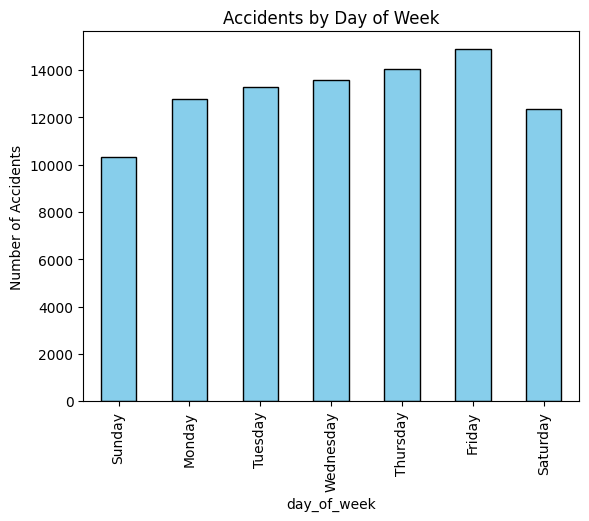

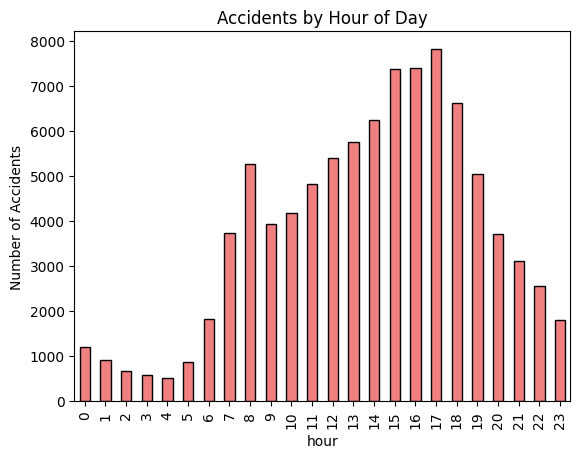

In [ ]:
import matplotlib.pyplot as plt

# Plot accidents by day of week
day_of_week_counts.plot(kind='bar', title='Accidents by Day of Week', color='skyblue', edgecolor='black')
plt.ylabel('Number of Accidents')
plt.show()

# Plot accidents by hour of day
hour_of_day_counts.plot(kind='bar', title='Accidents by Hour of Day', color='lightcoral', edgecolor='black')
plt.ylabel('Number of Accidents')
plt.show()


# **TASK 2**

In [ ]:
# Filter for motorcycle accidents by vehicle type
motorcycle_types = [3, 4, 5]  # Motorcycle 125cc and under, Motorcycle 125cc-500cc, Motorcycle over 500cc
df_motorcycles = df_vehicle[df_vehicle['vehicle_type'].isin(motorcycle_types)]

# Merge with the accident table to get day_of_week and time information
df_motorcycle_accidents = pd.merge(df_motorcycles, df_accident[['accident_index', 'day_of_week', 'time']], on='accident_index', how='left')

# 1. Count accidents by day of the week for motorcycles
motorcycle_day_of_week_counts = df_motorcycle_accidents['day_of_week'].value_counts().sort_index()

# Map days of the week to their names
motorcycle_day_of_week_counts.index = motorcycle_day_of_week_counts.index.map(day_of_week_mapping)

print("Motorcycle Accidents by Day of Week:")
print(motorcycle_day_of_week_counts)

# 2. Extract hour from the 'time' column and count accidents by hour for motorcycles
df_motorcycle_accidents['hour'] = df_motorcycle_accidents['time'].str.split(':').str[0].astype(int)

# Count accidents by hour of the day for motorcycles
motorcycle_hour_of_day_counts = df_motorcycle_accidents['hour'].value_counts().sort_index()

print("\nMotorcycle Accidents by Hour of Day:")
print(motorcycle_hour_of_day_counts)


Motorcycle Accidents by Day of Week:
day_of_week
Sunday       1738
Monday       1703
Tuesday      1765
Wednesday    1841
Thursday     2002
Friday       2119
Saturday     1830
Name: count, dtype: int64

Motorcycle Accidents by Hour of Day:
hour
0       96
1       90
2       43
3       37
4       41
5      111
6      243
7      531
8      445
9      388
10     497
11     648
12     786
13     961
14     976
15    1038
16    1126
17    1288
18    1075
19     836
20     669
21     504
22     348
23     221
Name: count, dtype: int64


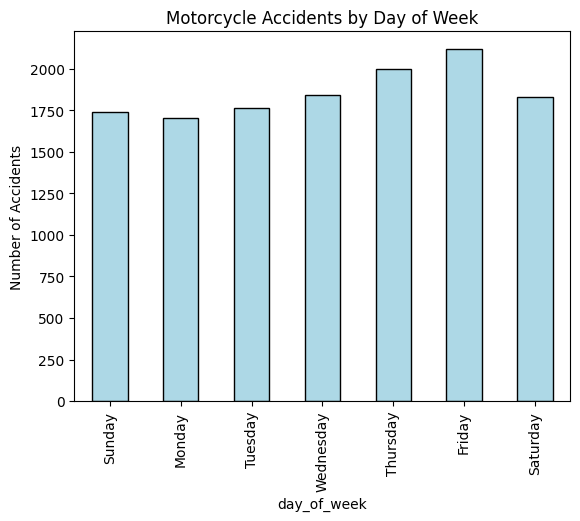

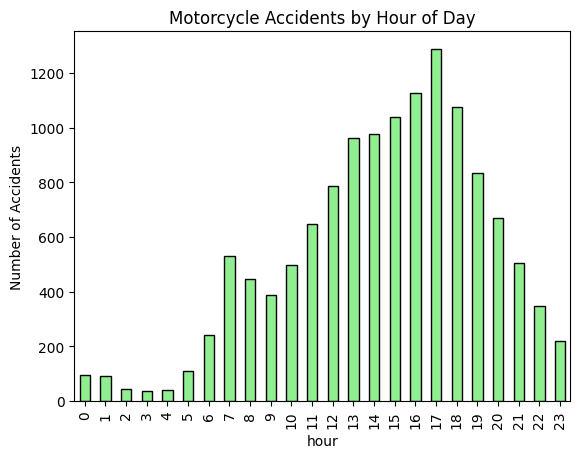

In [ ]:
# Plot motorcycle accidents by day of week
motorcycle_day_of_week_counts.plot(kind='bar', title='Motorcycle Accidents by Day of Week', color='lightblue', edgecolor='black')
plt.ylabel('Number of Accidents')
plt.show()

# Plot motorcycle accidents by hour of day
motorcycle_hour_of_day_counts.plot(kind='bar', title='Motorcycle Accidents by Hour of Day', color='lightgreen', edgecolor='black')
plt.ylabel('Number of Accidents')
plt.show()


# **TASK 3**

In [ ]:
# Filter for pedestrian casualties by casualty_class or casualty_type
df_pedestrian_casualties = df_casualty[(df_casualty['casualty_class'] == 3) | (df_casualty['casualty_type'] == 0)]

# Merge with the accident table to get day_of_week and time information
df_pedestrian_accidents = pd.merge(df_pedestrian_casualties, df_accident[['accident_index', 'day_of_week', 'time']], on='accident_index', how='left')

# 1. Count accidents by day of the week for pedestrians
pedestrian_day_of_week_counts = df_pedestrian_accidents['day_of_week'].value_counts().sort_index()

# Map days of the week to their names
pedestrian_day_of_week_counts.index = pedestrian_day_of_week_counts.index.map(day_of_week_mapping)

print("Pedestrian Accidents by Day of Week:")
print(pedestrian_day_of_week_counts)

# 2. Extract hour from the 'time' column and count accidents by hour for pedestrians
df_pedestrian_accidents['hour'] = df_pedestrian_accidents['time'].str.split(':').str[0].astype(int)

# Count accidents by hour of the day for pedestrians
pedestrian_hour_of_day_counts = df_pedestrian_accidents['hour'].value_counts().sort_index()

print("\nPedestrian Accidents by Hour of Day:")
print(pedestrian_hour_of_day_counts)


Pedestrian Accidents by Day of Week:
day_of_week
Sunday       1242
Monday       2207
Tuesday      2267
Wednesday    2247
Thursday     2366
Friday       2543
Saturday     1878
Name: count, dtype: int64

Pedestrian Accidents by Hour of Day:
hour
0      173
1      144
2       83
3       82
4       50
5       74
6      173
7      514
8     1060
9      607
10     644
11     725
12     809
13     833
14    1015
15    1672
16    1323
17    1274
18    1146
19     824
20     518
21     412
22     365
23     230
Name: count, dtype: int64


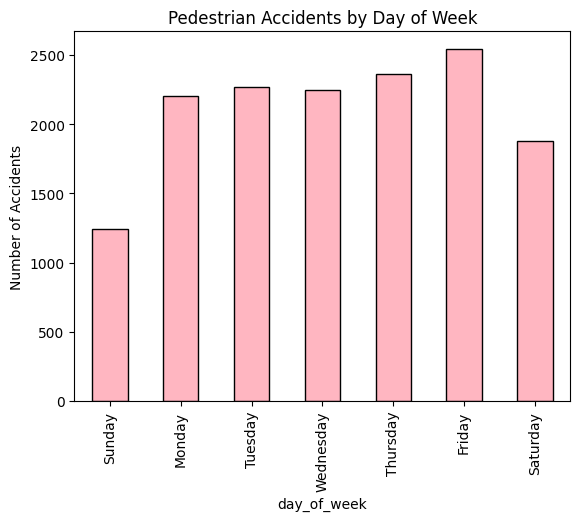

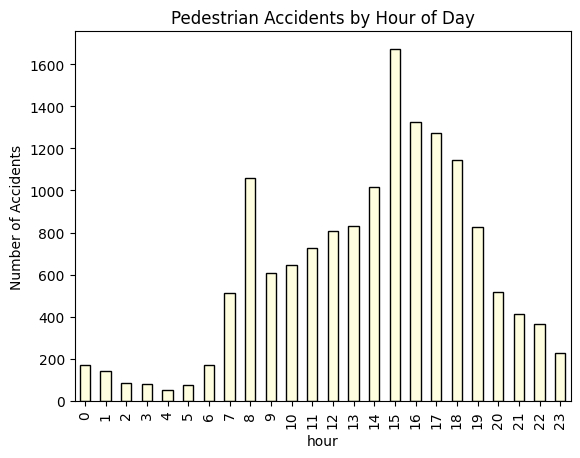

In [ ]:
# Plot pedestrian accidents by day of week
pedestrian_day_of_week_counts.plot(kind='bar', title='Pedestrian Accidents by Day of Week', color='lightpink', edgecolor='black')
plt.ylabel('Number of Accidents')
plt.show()

# Plot pedestrian accidents by hour of day
pedestrian_hour_of_day_counts.plot(kind='bar', title='Pedestrian Accidents by Hour of Day', color='lightyellow', edgecolor='black')
plt.ylabel('Number of Accidents')
plt.show()


# **TASK 4**

In [ ]:
!pip install mlxtend==0.23.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.9 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.2
    Uninstalling mlxtend-0.23.2:
      Successfully uninstalled mlxtend-0.23.2


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

# Preprocessing: Convert categorical variables into binary (dummy) variables
df_apriori = df_accident[['accident_severity', 'weather_conditions', 'road_type', 'speed_limit', 'light_conditions', 'day_of_week', 'road_surface_conditions']]

# Convert categorical variables to binary (0 or 1) for the Apriori algorithm
df_apriori = pd.get_dummies(df_apriori, drop_first=True)

# Convert 'accident_severity' into categorical labels and dummy variables
df_apriori = pd.get_dummies(df_apriori, columns=['accident_severity'], drop_first=True)

# Check for any columns that contain values other than 0 or 1
non_binary_columns = df_apriori.columns[df_apriori.applymap(lambda x: x not in [0, 1]).any()]
print(f"Columns with non-binary values: {non_binary_columns}")

# Replace non-binary values with 0
df_apriori = df_apriori.applymap(lambda x: 1 if x == 1 else (0 if x != 1 else x))

# Ensure there are no NaN values and all values are either 0 or 1
df_apriori = df_apriori.fillna(0).astype(int)

# Apply the Apriori algorithm to find frequent itemsets (using a minimum support threshold)
frequent_itemsets = apriori(df_apriori, min_support=0.01, use_colnames=True)

# Generate association rules with a minimum confidence threshold
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

<ipython-input-18-7978a6617ec0>:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  non_binary_columns = df_apriori.columns[df_apriori.applymap(lambda x: x not in [0, 1]).any()]


Columns with non-binary values: Index(['weather_conditions', 'road_type', 'speed_limit', 'light_conditions',
       'day_of_week', 'road_surface_conditions'],
      dtype='object')


<ipython-input-18-7978a6617ec0>:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_apriori = df_apriori.applymap(lambda x: 1 if x == 1 else (0 if x != 1 else x))
/usr/local/lib/python3.10/dist-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [ ]:
# Filter the rules to include only those where accident_severity is in the consequents
filtered_rules = rules[rules['consequents'].apply(lambda x: any('accident_severity' in item for item in x) and len(x) == 1)]

# Sort the filtered rules by lift and select the top 5
top_5_rules = filtered_rules.sort_values(by='lift', ascending=False).head(5)
# print("Association Rules related to Slight Accident Severity:")
# print(rules)

# Print the formatted output
print("\nRules Summary:")
for idx, row in top_5_rules.iterrows():
    antecedents = ', '.join(sorted(list(row['antecedents'])))
    consequents = ', '.join(sorted(list(row['consequents'])))
    print(f"{idx + 1}")
    print(f"{{{antecedents}}} -> {{{consequents}}}")
    print(f"{row['support']:.6f}")
    print(f"{row['confidence']:.6f}")
    print(f"{row['lift']:.6f}\n")


Rules Summary:
12
{road_type} -> {accident_severity_3}
0.051393
0.839964
1.072088

74
{road_surface_conditions, road_type} -> {accident_severity_3}
0.035987
0.834265
1.064814

71
{light_conditions, road_type} -> {accident_severity_3}
0.035976
0.834011
1.064490

164
{light_conditions, road_surface_conditions, road_type} -> {accident_severity_3}
0.027939
0.829427
1.058639

111
{road_surface_conditions, road_type, weather_conditions} -> {accident_severity_3}
0.033378
0.827624
1.056337



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


# **TASK 5**

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-20-e63b01086f98>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtered['latitude'].fillna('Unknown', inplace=True)
<ipython-input-20-e63b01086f98>:10: Set

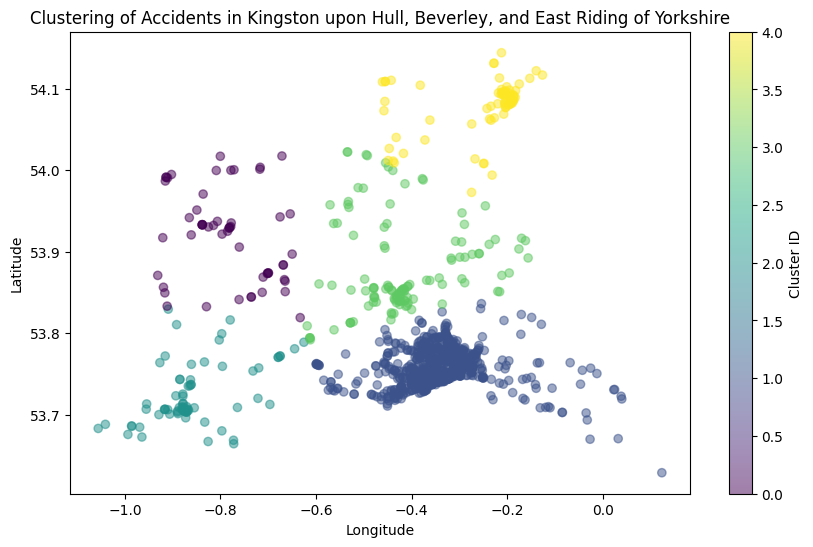

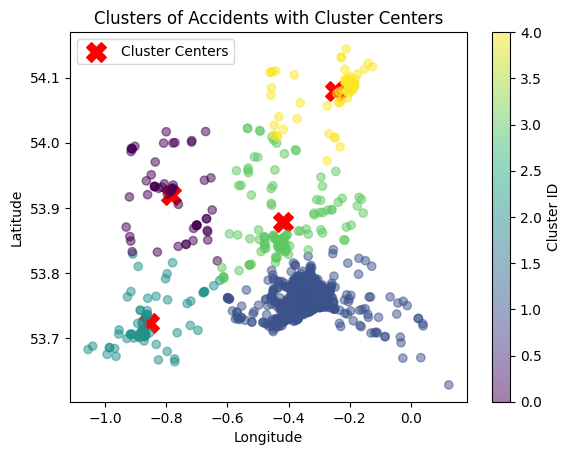

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Filter the DataFrame for the relevant local authorities
df_filtered = df_accident[df_accident['local_authority_district'].isin([220, 228, 231])]

# Optionally, fill missing values for location data if any (you could also drop them)
df_filtered['latitude'].fillna('Unknown', inplace=True)
df_filtered['longitude'].fillna('Unknown', inplace=True)

# Drop rows with 'Unknown' for latitude and longitude (optional, or use other imputation methods)
df_filtered = df_filtered.dropna(subset=['latitude', 'longitude'])

# Convert latitude and longitude to float
df_filtered['latitude'] = df_filtered['latitude'].astype(float)
df_filtered['longitude'] = df_filtered['longitude'].astype(float)

# Select only latitude and longitude for clustering
coordinates = df_filtered[['latitude', 'longitude']]

# Normalize the coordinates before clustering (important for distance-based algorithms like K-Means)
scaler = StandardScaler()
coordinates_scaled = scaler.fit_transform(coordinates)

# Apply K-Means clustering (you can experiment with the number of clusters)
kmeans = KMeans(n_clusters=5, random_state=42)
df_filtered['cluster'] = kmeans.fit_predict(coordinates_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 6))

# Plot the clustered accidents
plt.scatter(df_filtered['longitude'], df_filtered['latitude'], c=df_filtered['cluster'], cmap='viridis', alpha=0.5)
plt.title("Clustering of Accidents in Kingston upon Hull, Beverley, and East Riding of Yorkshire")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Cluster ID")
plt.show()

# Optional: Display cluster centers on the map
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot the centers
plt.scatter(cluster_centers[:, 1], cluster_centers[:, 0], marker='X', s=200, c='red', label='Cluster Centers')
plt.scatter(df_filtered['longitude'], df_filtered['latitude'], c=df_filtered['cluster'], cmap='viridis', alpha=0.5)
plt.title("Clusters of Accidents with Cluster Centers")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.colorbar(label="Cluster ID")
plt.show()


# **TASK 6**

In [ ]:
# !python -m pip install fbprophet

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-22-a675dc10c8be>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_warwickshire['week'] = df_warwickshire['date'].dt.to_period('W')
<ipython-input-22-a675dc10c8be>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

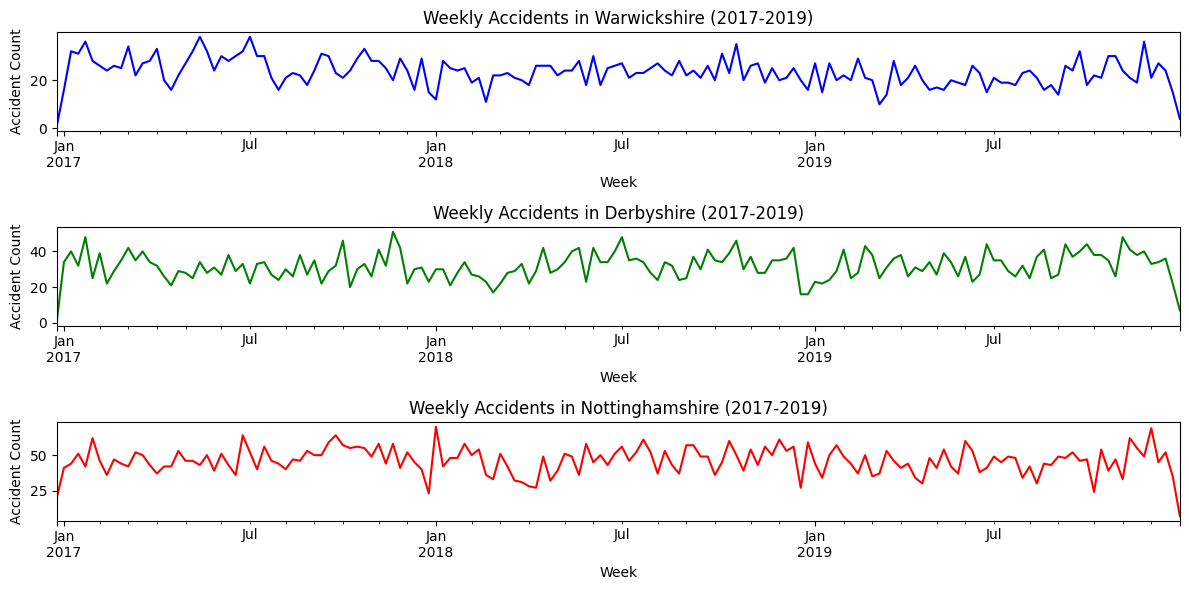

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


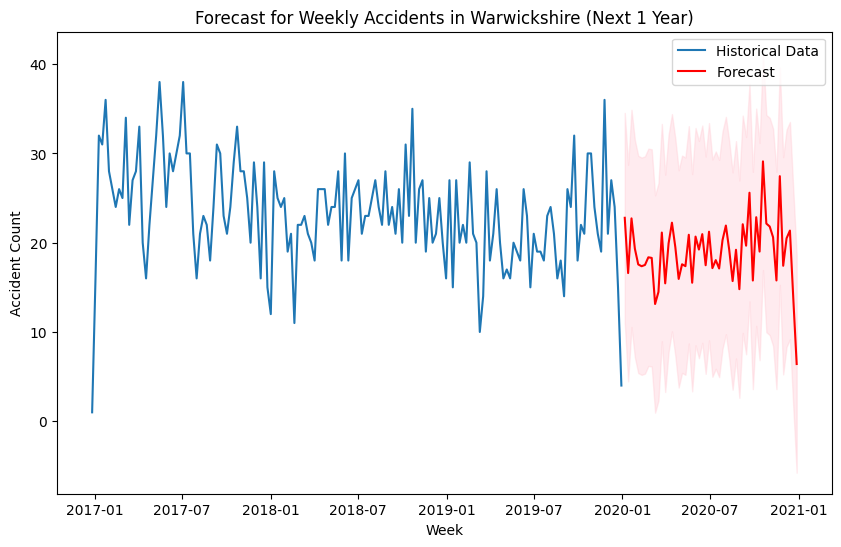

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


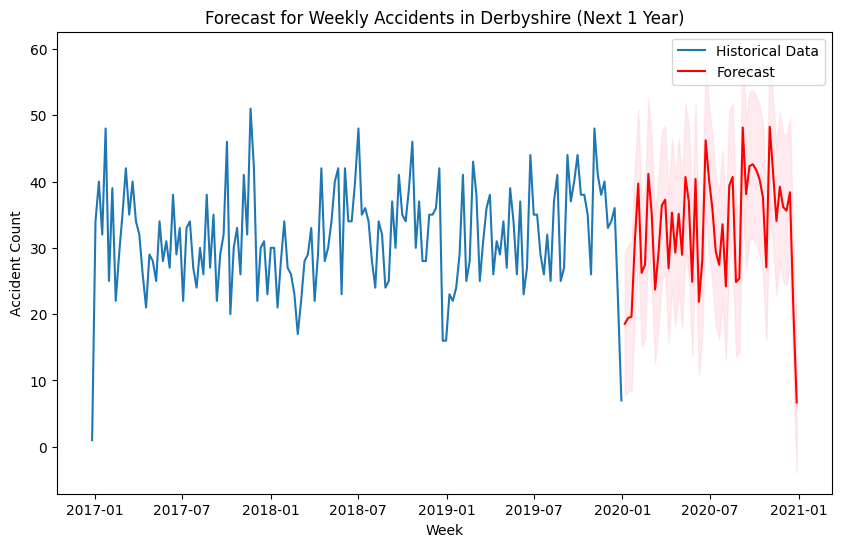

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


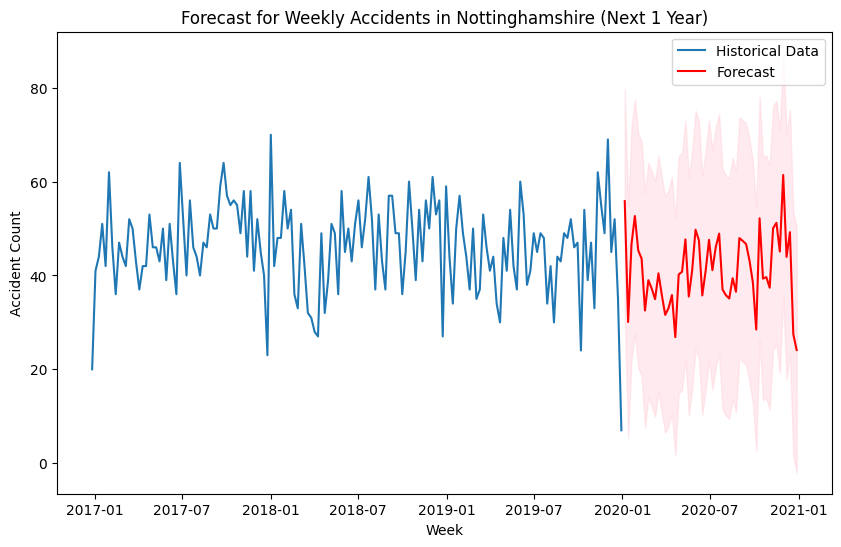

MAE for the model: 5.65
MAE for the model: 8.71
MAE for the model: 9.21


In [ ]:
import pandas as pd
import sqlite3
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Connect to the SQLite database
conn = sqlite3.connect('/content/drive/MyDrive/Rough Datas/accident_data_v1.0.0_2023.db')

# Query data for specific police forces and years 2017-2019
query = """
SELECT accident_index, accident_year, accident_reference, date, police_force
FROM accident
WHERE police_force IN (23, 30, 31) AND accident_year BETWEEN 2017 AND 2019
"""
df = pd.read_sql(query, conn)

# Close the connection
conn.close()

# Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')

# Filter the data for the police forces of interest
df_warwickshire = df[df['police_force'] == 23]
df_derbyshire = df[df['police_force'] == 30]
df_nottinghamshire = df[df['police_force'] == 31]

# Group the data by week and calculate the weekly accident counts
df_warwickshire['week'] = df_warwickshire['date'].dt.to_period('W')
df_derbyshire['week'] = df_derbyshire['date'].dt.to_period('W')
df_nottinghamshire['week'] = df_nottinghamshire['date'].dt.to_period('W')

# Convert Period to Datetime (start of the week)
df_warwickshire['week_start'] = df_warwickshire['week'].dt.start_time
df_derbyshire['week_start'] = df_derbyshire['week'].dt.start_time
df_nottinghamshire['week_start'] = df_nottinghamshire['week'].dt.start_time

# Get the weekly counts
df_warwickshire_weekly = df_warwickshire.groupby('week_start').size()
df_derbyshire_weekly = df_derbyshire.groupby('week_start').size()
df_nottinghamshire_weekly = df_nottinghamshire.groupby('week_start').size()

# Plot the weekly accident counts for each police force
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
df_warwickshire_weekly.plot(title='Weekly Accidents in Warwickshire (2017-2019)', color='blue')
plt.xlabel('Week')
plt.ylabel('Accident Count')

plt.subplot(3, 1, 2)
df_derbyshire_weekly.plot(title='Weekly Accidents in Derbyshire (2017-2019)', color='green')
plt.xlabel('Week')
plt.ylabel('Accident Count')

plt.subplot(3, 1, 3)
df_nottinghamshire_weekly.plot(title='Weekly Accidents in Nottinghamshire (2017-2019)', color='red')
plt.xlabel('Week')
plt.ylabel('Accident Count')

plt.tight_layout()
plt.show()

# Prepare the data for SARIMA (seasonal ARIMA) model, as it is often used for time series with seasonality
# Define a function to create SARIMA models for each region
def create_sarima_model(df_weekly, title):
    # Fit a SARIMA model
    sarima_model = SARIMAX(df_weekly,
                           order=(1, 1, 1),  # (p,d,q)
                           seasonal_order=(1, 1, 1, 52),  # (P,D,Q,S) where S=52 for weekly data
                           enforce_stationarity=False,
                           enforce_invertibility=False)
    results = sarima_model.fit()

    # Plot the forecast
    forecast = results.get_forecast(steps=52)  # Forecast for the next 52 weeks
    forecast_mean = forecast.predicted_mean
    forecast_conf_int = forecast.conf_int()

    # Plot the forecast
    plt.figure(figsize=(10, 6))
    plt.plot(df_weekly.index, df_weekly, label='Historical Data')
    plt.plot(forecast_mean.index, forecast_mean, color='red', label='Forecast')
    plt.fill_between(forecast_mean.index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], color='pink', alpha=0.3)
    plt.title(f"Forecast for Weekly Accidents in {title} (Next 1 Year)")
    plt.xlabel('Week')
    plt.ylabel('Accident Count')
    plt.legend()
    plt.show()

    return results

# Apply SARIMA model to each policing area and plot
warwickshire_results = create_sarima_model(df_warwickshire_weekly, "Warwickshire")
derbyshire_results = create_sarima_model(df_derbyshire_weekly, "Derbyshire")
nottinghamshire_results = create_sarima_model(df_nottinghamshire_weekly, "Nottinghamshire")

# To evaluate the model, we can calculate the Mean Absolute Error (MAE) on the training data
def evaluate_model(results, df_weekly):
    forecast_train = results.get_prediction(start=0, end=len(df_weekly)-1)
    forecast_values = forecast_train.predicted_mean
    mae = mean_absolute_error(df_weekly, forecast_values)
    print(f"MAE for the model: {mae:.2f}")

# Evaluate the models
evaluate_model(warwickshire_results, df_warwickshire_weekly)
evaluate_model(derbyshire_results, df_derbyshire_weekly)
evaluate_model(nottinghamshire_results, df_nottinghamshire_weekly)


In [ ]:
df.tail()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,accident_index,accident_year,accident_reference,date,police_force
15971,201931P218119,2019,31P218119,2019-11-14,31
15972,201931P227419,2019,31P227419,2019-11-17,31
15973,201931P247119,2019,31P247119,2019-12-20,31
15974,201931P247419,2019,31P247419,2019-12-18,31
15975,201931P254919,2019,31P254919,2019-11-11,31


# **TASK 7**

In [ ]:
df_accident.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,hour
0,2020010219808,2020,010219808,521389.0,175144.0,-0.254001,51.462262,1,3,1,...,1,9,9,0,0,1,3,2,E01004576,9
1,2020010220496,2020,010220496,529337.0,176237.0,-0.139253,51.470327,1,3,1,...,1,1,1,0,0,1,1,2,E01003034,13
2,2020010228005,2020,010228005,526432.0,182761.0,-0.178719,51.529614,1,3,1,...,4,1,2,0,0,1,1,2,E01004726,1
3,2020010228006,2020,010228006,538676.0,184371.0,-0.001683,51.54121,1,2,1,...,4,1,1,0,0,1,1,2,E01003617,1
4,2020010228011,2020,010228011,529324.0,181286.0,-0.137592,51.515704,1,3,1,...,4,1,1,0,0,1,1,2,E01004763,2


In [ ]:
import pandas as pd

# Load data (assuming df_accident is your DataFrame)
df_accident['date'] = pd.to_datetime(df_accident['date'], format='%d/%m/%Y')

# Filter for Hull City (assuming 228 represents Kingston upon Hull)
df_hull = df_accident[df_accident['local_authority_district'] == 228]

# Filter for accidents from January to March 2020
df_hull_2020 = df_hull[(df_hull['date'].dt.year == 2020) & (df_hull['date'].dt.month <= 3)]

# Group by LSOA and count the accidents
accidents_per_lsoa = df_hull_2020.groupby('lsoa_of_accident_location').size().reset_index(name='accident_count')

# Sort by accident_count to find the top 3 LSOAs
top_3_lsoas = accidents_per_lsoa.sort_values(by='accident_count', ascending=False).head(3)

# Show top 3 LSOAs
print(top_3_lsoas)


   lsoa_of_accident_location  accident_count
34                 E01012817              10
43                 E01012848               7
70                 E01012889               7


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Filter data for the top 3 LSOAs from January to June 2020
df_top_3_lsoas = df_hull[(df_hull['lsoa_of_accident_location'].isin(top_3_lsoas['lsoa_of_accident_location'])) &
                          (df_hull['date'].dt.year == 2020) &
                          (df_hull['date'].dt.month <= 6)]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Group by date and LSOA to count accidents
df_accidents_daily = df_top_3_lsoas.groupby(['date', 'lsoa_of_accident_location']).size().reset_index(name='daily_accidents')

# Pivot data to create separate time series for each LSOA
df_accidents_pivot = df_accidents_daily.pivot(index='date', columns='lsoa_of_accident_location', values='daily_accidents')

# Fill missing values (if any) with 0 accidents on those days
df_accidents_pivot = df_accidents_pivot.fillna(0)

# Show the data
print(df_accidents_pivot.head())


lsoa_of_accident_location  E01012817  E01012848  E01012889
date                                                      
2020-01-02                       2.0        0.0        0.0
2020-01-03                       1.0        0.0        0.0
2020-01-10                       0.0        1.0        1.0
2020-01-13                       1.0        0.0        0.0
2020-01-17                       1.0        0.0        0.0


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting paramet

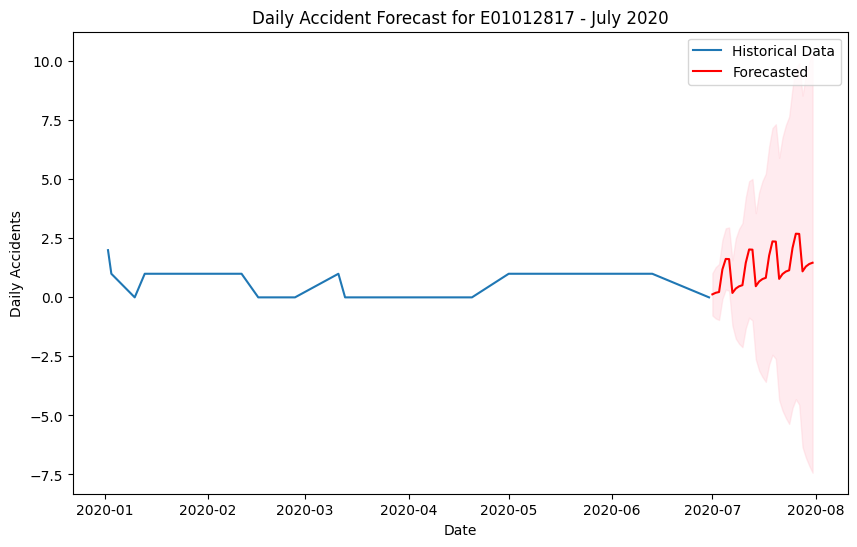

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization

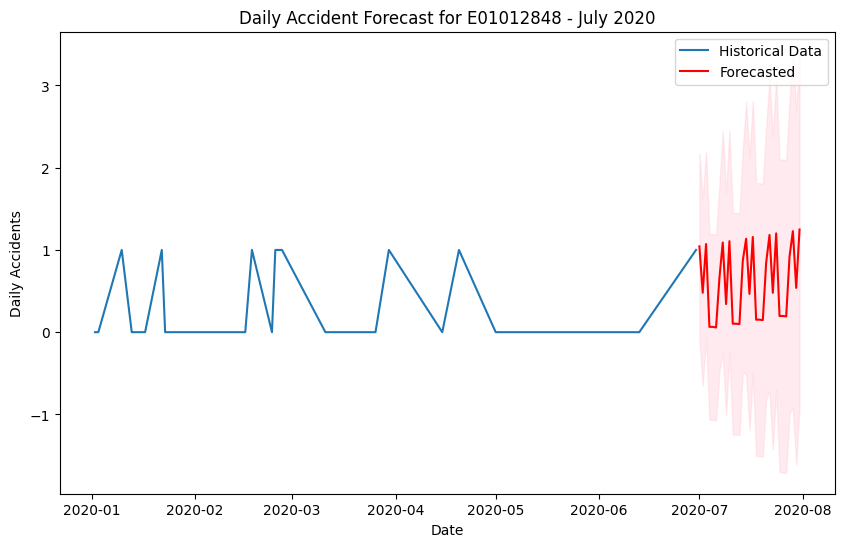

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  retu

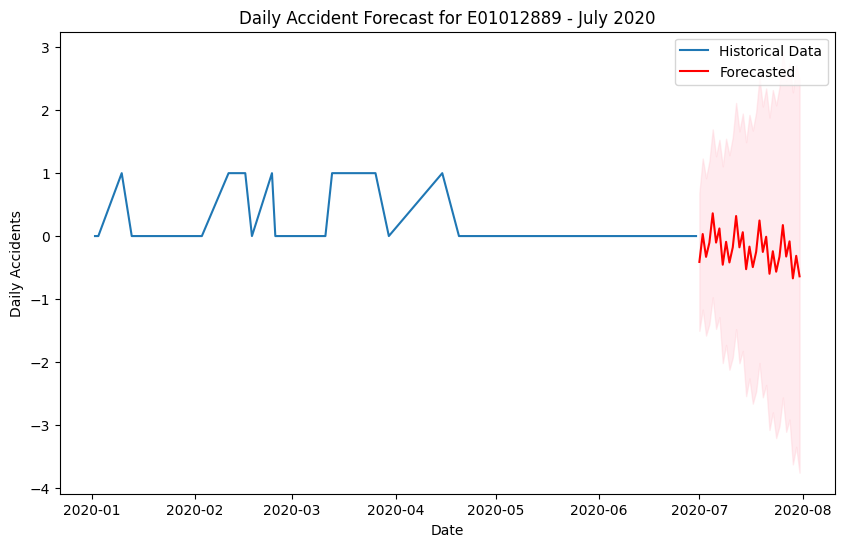

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Define function to apply SARIMA and forecast
def apply_sarima(df, lsoa_name):
    # Select the time series for the LSOA
    series = df[lsoa_name]

    # Fit a SARIMA model
    model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,7))  # Adjust order based on model diagnostics
    results = model.fit()

    # Forecast for the next month (July 2020)
    forecast = results.get_forecast(steps=31)  # 31 days for July
    forecast_index = pd.date_range(start='2020-07-01', periods=31, freq='D')

    # Get forecast values and confidence intervals
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    # Plot forecast
    plt.figure(figsize=(10,6))
    plt.plot(series, label='Historical Data')
    plt.plot(forecast_index, forecast_mean, color='red', label='Forecasted')
    plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
    plt.title(f"Daily Accident Forecast for {lsoa_name} - July 2020")
    plt.xlabel("Date")
    plt.ylabel("Daily Accidents")
    plt.legend()
    plt.show()

    return forecast_mean

# Apply SARIMA model for each LSOA
for lsoa in top_3_lsoas['lsoa_of_accident_location']:
    apply_sarima(df_accidents_pivot, lsoa)


# **TASK 8**

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Number of nodes: 91210
Number of edges: 7734717
Network density: 0.0019
Average degree: 169.6024


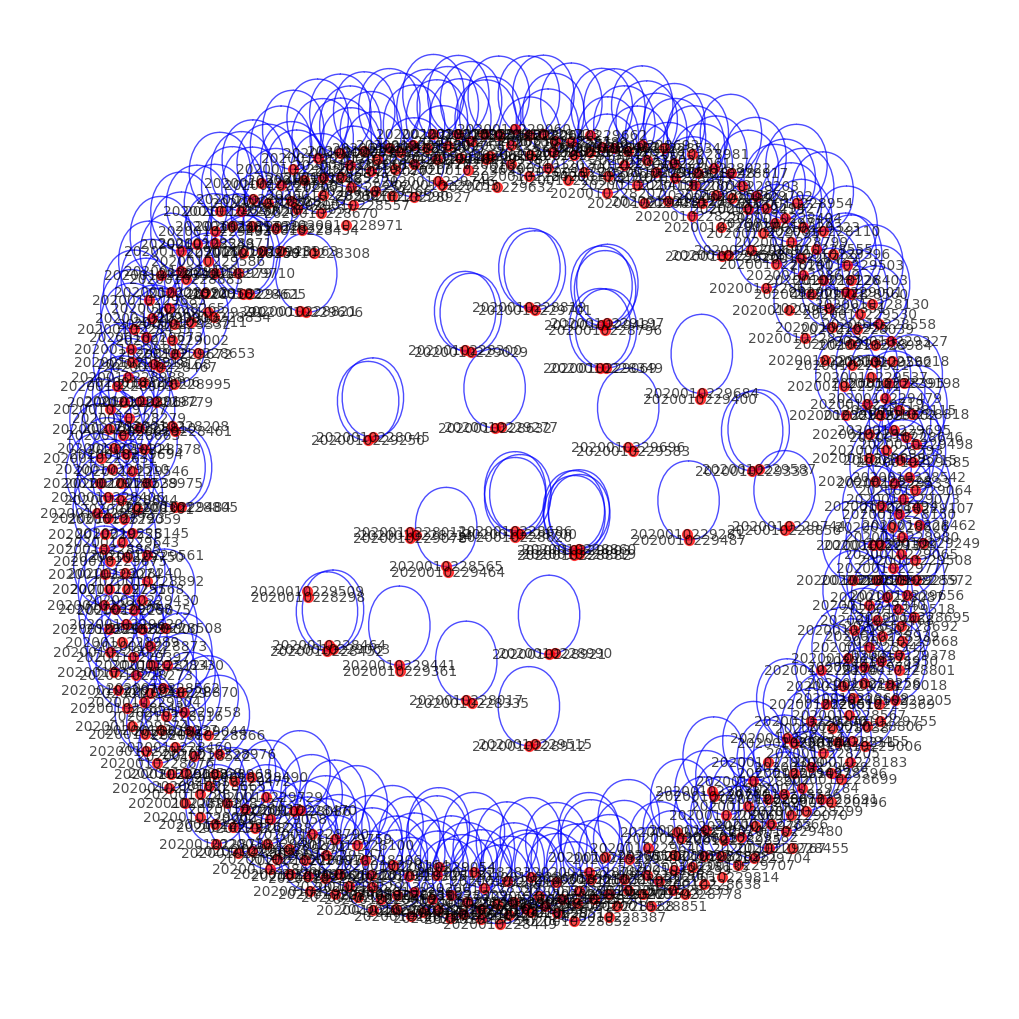

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df_accident, df_vehicle, and df_lsoa are already loaded as per your previous steps

# Create a graph object
G = nx.Graph()

# 1. Add nodes (accidents as nodes)
# Each accident will be a node
accident_nodes = df_accident['accident_index'].unique()
G.add_nodes_from(accident_nodes)

# 2. Add edges (create relationships between accidents)
# Example 1: Add edges between accidents that share a vehicle
vehicle_accidents = df_vehicle.groupby('accident_index')['vehicle_reference'].unique()
for accident, vehicles in vehicle_accidents.items():
    for i, vehicle1 in enumerate(vehicles):
        for vehicle2 in vehicles[i+1:]:
            if not G.has_edge(accident, accident):  # avoid self-loop
                G.add_edge(accident, accident)  # if necessary, add this type of edge
            else:
                # Add edges for accidents with shared vehicles
                G.add_edge(accident, vehicle2)

# Example 2: Add edges between accidents in the same LSOA
lsoa_accidents = df_accident.groupby('lsoa_of_accident_location')['accident_index'].unique()
for lsoa, accidents in lsoa_accidents.items():
    for i, accident1 in enumerate(accidents):
        for accident2 in accidents[i+1:]:
            G.add_edge(accident1, accident2)

# 3. Calculate basic network characteristics
# Nodes
num_nodes = G.number_of_nodes()

# Edges
num_edges = G.number_of_edges()

# Network Density (ratio of actual edges to maximum possible edges)
density = nx.density(G)

# Average degree (average number of neighbors per node)
average_degree = sum(dict(G.degree()).values()) / num_nodes

# Print network characteristics
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Network density: {density:.4f}")
print(f"Average degree: {average_degree:.4f}")

# 4. Visualize the network
# Optional: if the network is too large, consider plotting a sample subset
plt.figure(figsize=(10, 10))

# Sample 500 nodes randomly
sampled_nodes = list(G.nodes)[:500]  # Adjust the number based on how many you want to plot
G_sample = G.subgraph(sampled_nodes)

# Draw the sampled graph
nx.draw(G_sample, with_labels=True, node_size=50, font_size=10, edge_color='b', alpha=0.7, node_color='r')
plt.show()



# **TASK 9**

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


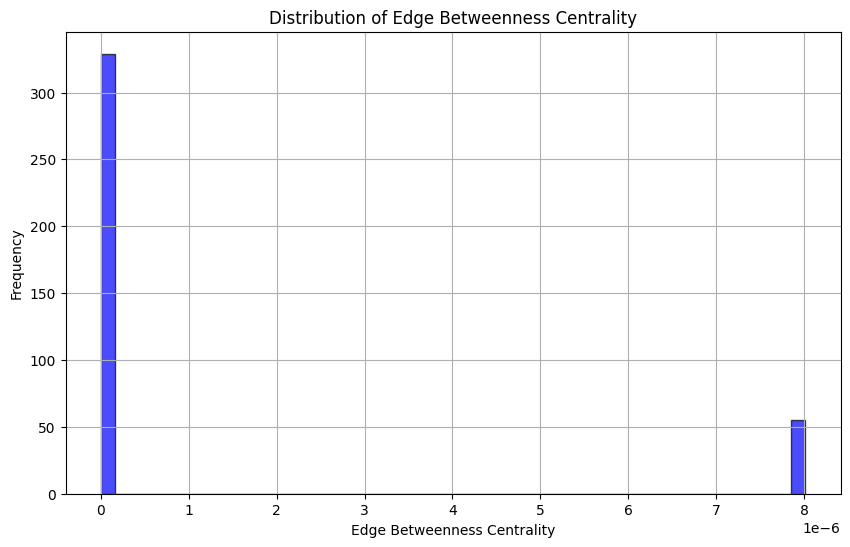

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Assuming G is the graph created from the previous steps

# Calculate edge betweenness centrality
edge_betweenness = nx.edge_betweenness_centrality(G_sample, normalized=True)

# Plot the distribution of edge betweenness centrality values
plt.figure(figsize=(10, 6))
plt.hist(list(edge_betweenness.values()), bins=50, color='b', edgecolor='black', alpha=0.7)
plt.title("Distribution of Edge Betweenness Centrality")
plt.xlabel("Edge Betweenness Centrality")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# **TASK 10**

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Girvan-Newman Results:
Number of clusters: 453
Sizes of clusters: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 

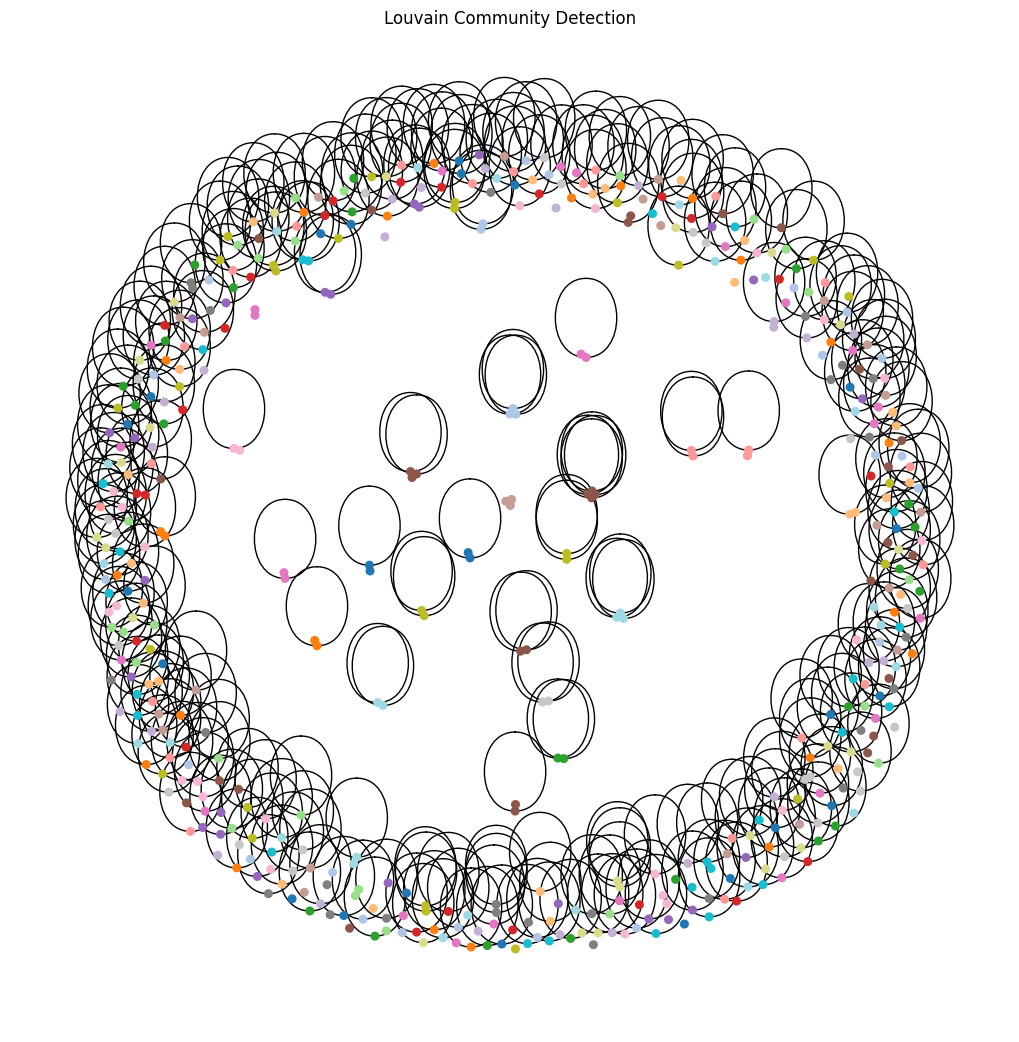

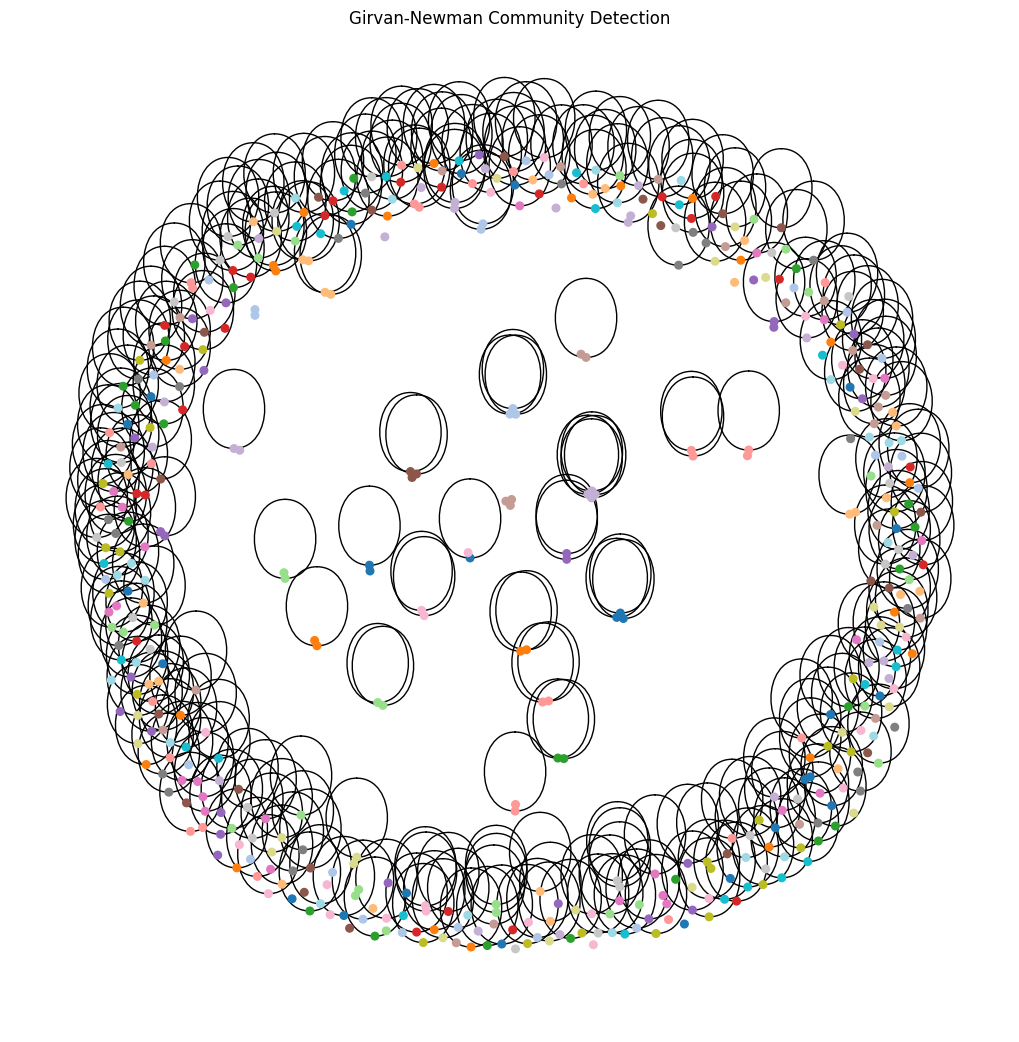

In [ ]:
import networkx as nx
from networkx.algorithms.community import girvan_newman
from community import community_louvain  # Install with `pip install python-louvain`
import matplotlib.pyplot as plt

# Assume G is the graph created earlier

# -------------------------------
# 1. Girvan-Newman Algorithm
# -------------------------------
# Apply the Girvan-Newman algorithm
girvan_newman_communities = list(girvan_newman(G_sample))
# Use the first division (top level) of communities
gn_top_level = tuple(sorted(c) for c in girvan_newman_communities[0])

# Get number of clusters and size of each cluster
gn_num_clusters = len(gn_top_level)
gn_cluster_sizes = [len(cluster) for cluster in gn_top_level]

# -------------------------------
# 2. Louvain Algorithm
# -------------------------------
# Apply the Louvain algorithm
louvain_partition = community_louvain.best_partition(G_sample)

# Group nodes by community
louvain_communities = {}
for node, community in louvain_partition.items():
    if community not in louvain_communities:
        louvain_communities[community] = []
    louvain_communities[community].append(node)

# Get number of clusters and size of each cluster
louvain_num_clusters = len(louvain_communities)
louvain_cluster_sizes = [len(cluster) for cluster in louvain_communities.values()]

# -------------------------------
# Compare Results
# -------------------------------
print("Girvan-Newman Results:")
print(f"Number of clusters: {gn_num_clusters}")
print(f"Sizes of clusters: {gn_cluster_sizes}")

print("\nLouvain Results:")
print(f"Number of clusters: {louvain_num_clusters}")
print(f"Sizes of clusters: {louvain_cluster_sizes}")

# -------------------------------
# Visualization of Louvain Communities
# -------------------------------
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_sample)  # Spring layout for visualization
colors = [louvain_partition[node] for node in G_sample.nodes()]
nx.draw(G_sample, pos, node_color=colors, with_labels=False, node_size=30, cmap=plt.cm.tab20)
plt.title("Louvain Community Detection")
plt.show()

# Optional: Visualization of Girvan-Newman Communities
plt.figure(figsize=(10, 10))
gn_colors = [0] * len(G_sample.nodes())
for i, cluster in enumerate(gn_top_level):
    for node in cluster:
        gn_colors[list(G_sample.nodes()).index(node)] = i
nx.draw(G_sample, pos, node_color=gn_colors, with_labels=False, node_size=30, cmap=plt.cm.tab20)
plt.title("Girvan-Newman Community Detection")
plt.show()
